In [4]:
# 05_EDA - Sensor EDA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_data_dir():
    for root in [Path.cwd(), *Path.cwd().parents]:
        d = root / "data"
        if (d / "processed" / "preprocessed_data.csv").exists():
            return d
    raise FileNotFoundError("preprocessed_data.csv를 찾지 못함")

DATA_DIR = find_data_dir()
DATA_PATH = DATA_DIR / "processed" / "preprocessed_data.csv"

data = pd.read_csv(DATA_PATH, parse_dates=["TimeStamp"])

SIGNALS = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
WINDOW = 10
RMS_COLS = [f"{c}_RMS" for c in SIGNALS]

print("전처리 데이터 로드:", DATA_PATH)
print("rows:", len(data))
print("segments:", data.groupby("source")["segment_id"].nunique().to_dict())


SIGNALS = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
WINDOW = 10
RMS_COLS = [f"{c}_RMS" for c in SIGNALS]

# 04_Preprocessing 결과 확인
required = ["TimeStamp", "elapsed_sec", "dt_sec", "segment_id", "source", *SIGNALS]
missing = [c for c in required if c not in data.columns]
if missing:
    raise ValueError(f"04_Preprocessing 결과 누락: {missing}")

# 1. Segment 내부 Rolling RMS
def add_rms(df, window=WINDOW):
    out = df.copy()
    for c in SIGNALS:
        out[f"{c}_RMS"] = out.groupby("segment_id", sort=False)[c].transform(
            lambda x: np.sqrt(x.pow(2).rolling(window, min_periods=window).mean())
        )
    return out

data_eda = add_rms(data)
normal = data_eda[data_eda.source == "normal"].copy()
abnormal = data_eda[data_eda.source == "abnormal"].copy()

# 2. Normal RMS 기준 IQR
def iqr_bounds(df):
    q1, q3 = df.quantile(.25), df.quantile(.75)
    iqr = q3 - q1
    return pd.DataFrame({
        "lower": q1 - 1.5 * iqr,
        "upper": q3 + 1.5 * iqr,
        "q1": q1, "q3": q3
    })

bounds = iqr_bounds(normal[RMS_COLS])

# 3. RMS 판정 가능 여부 + 정상범위 여부
def add_rms_flag(df):
    out = df.copy()
    out["RMS_evaluable"] = out[RMS_COLS].notna().all(axis=1)

    flags = pd.DataFrame(index=out.index)
    for c in RMS_COLS:
        flags[c] = (out[c] < bounds.loc[c, "lower"]) | (out[c] > bounds.loc[c, "upper"])

    out["RMS_outlier"] = flags.any(axis=1) & out["RMS_evaluable"]
    out["RMS_normal"] = ~out["RMS_outlier"] & out["RMS_evaluable"]
    return out

normal = add_rms_flag(normal)
abnormal = add_rms_flag(abnormal)

# 4. 기본 결과
print("[Normal]")
print(f"rows           : {len(normal):,}")
print(f"RMS evaluable  : {normal.RMS_evaluable.sum():,}")
print(f"RMS outlier    : {normal.RMS_outlier.sum():,}")

print("\n[Abnormal]")
print(f"rows           : {len(abnormal):,}")
print(f"RMS evaluable  : {abnormal.RMS_evaluable.sum():,}")
print(f"RMS not eval   : {(~abnormal.RMS_evaluable).sum():,}")
print(f"RMS detected   : {abnormal.RMS_outlier.sum():,}")
print(f"RMS missed     : {abnormal.RMS_normal.sum():,}")

display(bounds.round(4))

전처리 데이터 로드: c:\Users\astra\Desktop\K_eng\data\processed\preprocessed_data.csv
rows: 20599
segments: {'abnormal': 21, 'normal': 599}


[Normal]
rows           : 19,999
RMS evaluable  : 14,871
RMS outlier    : 75

[Abnormal]
rows           : 600
RMS evaluable  : 428
RMS not eval   : 172
RMS detected   : 235
RMS missed     : 193


,lower,upper,q1,q3
AI0_Vibration_RMS,-0.0090,0.1382,0.0462,0.0830
AI1_Vibration_RMS,-0.1098,0.3177,0.0505,0.1574
AI2_Current_RMS,-14.6243,252.2311,85.4465,152.1603


In [5]:
# 5. 공식 segment 단위 요약
segment_summary = (
    normal.groupby("segment_id", sort=False)
    .agg(
        start_time=("TimeStamp", "first"),
        end_time=("TimeStamp", "last"),
        samples=("segment_id", "size"),
        duration_sec=("elapsed_sec", lambda x: x.max() - x.min()),
        rms_evaluable=("RMS_evaluable", "sum"),
        rms_outliers=("RMS_outlier", "sum"),
        rms_normal_rate=("RMS_normal", "mean"),
    )
)

display(segment_summary.describe().round(3))

,start_time,end_time,samples,duration_sec,rms_evaluable,rms_outliers,rms_normal_rate
count,599,599,599.000,599.000,599.000,599.000,599.000
mean,2022-07-12 00:37:56.487509,2022-07-12 00:37:59.726240,33.387,3.239,24.826,0.125,0.614
min,2022-07-12 00:00:00.019000,2022-07-12 00:00:04.019000,1.000,0.000,0.000,0.000,0.000
25%,2022-07-12 00:18:48.541000,2022-07-12 00:18:49.341000,20.000,1.900,11.000,0.000,0.550
50%,2022-07-12 00:37:49.246000,2022-07-12 00:37:53.946000,37.000,3.600,28.000,0.000,0.750
75%,2022-07-12 00:56:45.350000,2022-07-12 00:56:48.100000,50.000,4.900,41.000,0.000,0.820
max,2022-07-12 01:16:51.528000,2022-07-12 01:16:55.828000,50.000,4.900,41.000,15.000,0.820
std,NaN,NaN,16.385,1.639,15.630,1.016,0.279


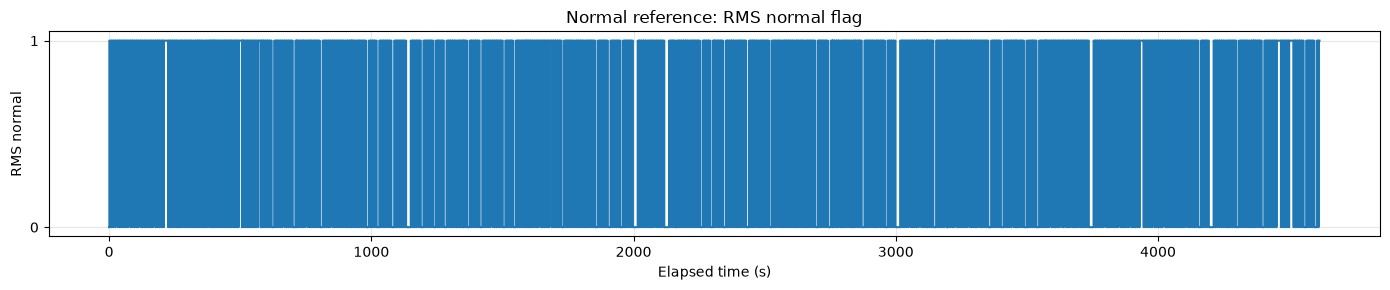

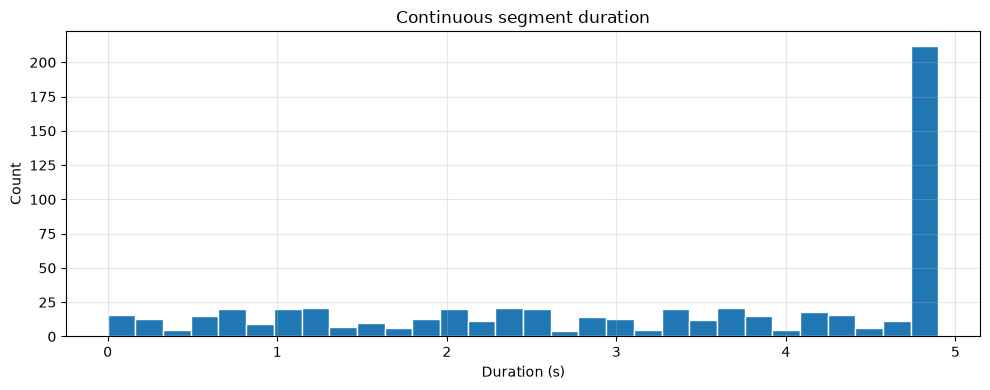

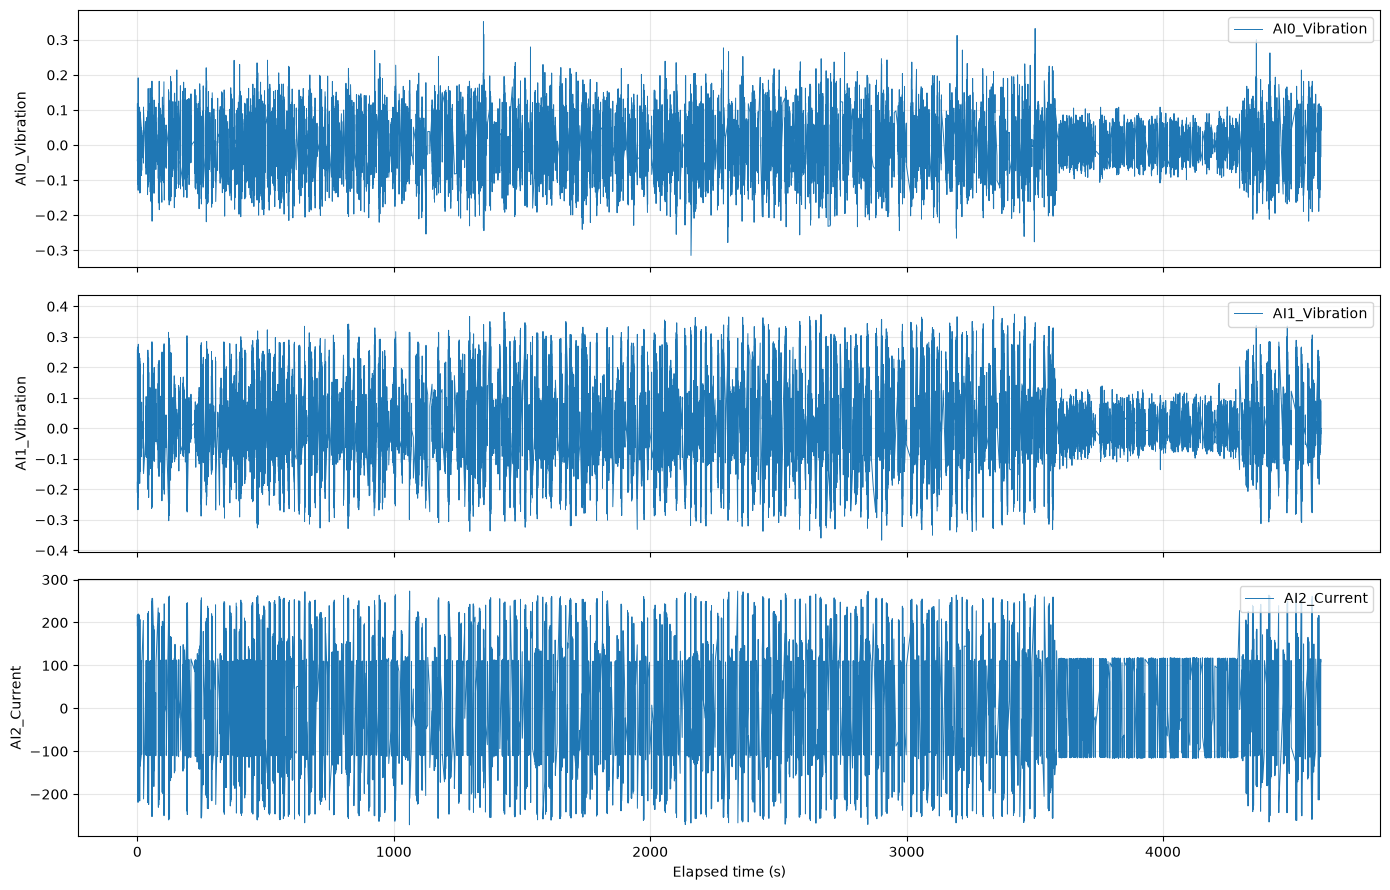

,AI0_Vibration,AI1_Vibration,AI2_Current
AI0_Vibration,1.000,0.368,0.004
AI1_Vibration,0.368,1.000,0.001
AI2_Current,0.004,0.001,1.000


In [6]:
# 6. Normal에서 RMS 정상/이상 상태
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(normal["elapsed_sec"], normal["RMS_normal"].astype(int), drawstyle="steps-post")
ax.set(title="Normal reference: RMS normal flag", xlabel="Elapsed time (s)", ylabel="RMS normal")
ax.set_yticks([0, 1])
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

# 7. 공식 segment 길이 분포
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(segment_summary["duration_sec"], bins=30, edgecolor="white")
ax.set(title="Continuous segment duration", xlabel="Duration (s)", ylabel="Count")
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

# 8. 센서 시계열
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, c in zip(axes, SIGNALS):
    ax.plot(normal["elapsed_sec"], normal[c], linewidth=.7, label=c)
    ax.set_ylabel(c)
    ax.legend(loc="upper right")
    ax.grid(alpha=.3)

axes[-1].set_xlabel("Elapsed time (s)")
plt.tight_layout()
plt.show()

# 9. 센서 상관관계
display(normal[SIGNALS].corr().round(3))